<center>
<img src="https://2526moodle.isel.pt/pluginfile.php/1/core_admin/logocompact/300x300/1757490446/logo2.png" width="250">
<h3>Licenciatura em Engenharia Informática e Multimédia</h3><br>
Ano Letivo 2025/2026 —— Semestre de Inverno<br>
<h3>Aprendizagem Automática (AA)</h3><br>
Docente: Gonçalo Caetano Marques
<h3>1º Trabalho Laboratorial – Pima Indians Diabetes Dataset</h3>    
<br>
Discentes: Rafael Martins <b>A49725</b> ——  Rafael Lemos <b> A51628 </b> —— Tomás Camacho  <b>A52046</b><br>

<div style="text-align:center">Turma 51D<br>21 de Novembro 2025</div>
</center>

## 1. Introdução

O objetivo deste trabalho é analisar o *Pima Indians Diabetes Dataset* para construir um modelo de classificação binária. O modelo deve prever se uma paciente tem ou não diabetes, com base em 8 características de diagnóstico.

O enunciado exige o treino e avaliação de, no mínimo, três classificadores binários, sendo um deles o `RandomForestClassifier`. O foco principal será a criação de um *pipeline* de classificação robusto, que inclua:

1.  Um pré-processamento rigoroso dos dados.
2.  A escolha de uma metodologia de treino/teste que forneça uma "estimação fidedigna".
3.  A seleção e otimização de hiper-parâmetros.
4.  Uma análise comparativa usando "métricas apropriadas".
5.  Uma investigação sobre o benefício da "normalização" dos dados.

Este relatório seguirá esta estrutura, justificando cada decisão com base na teoria de aprendizagem automática e nos materiais de apoio.

In [ ]:
# Setup: Importar bibliotecas necessárias
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento e Pipelines
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier

# Métricas e Avaliação
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    precision_recall_curve,
)

print("Bibliotecas importadas com sucesso.")

Bibliotecas importadas com sucesso.


## 2. Análise Exploratória e Pré-processamento dos Dados

O primeiro passo é carregar os dados e realizar uma análise exploratória para identificar potenciais problemas, como dados em falta, desequilíbrio de classes ou a necessidade de normalização.

In [23]:
# Carregar o ficheiro pickle
with open('pimaDiabetes.p', 'rb') as f:
    D = pickle.load(f)

# Criar um DataFrame do Pandas para facilitar a manipulação
# D.keys() mostrou que temos 'data', 'target' e 'feature_names'
df = pd.DataFrame(D['data'], columns=D['feature_names'])
df['target'] = D['target']

print("Dataset carregado para DataFrame. Dimensões:", df.shape)
print("\nAmostra dos dados (head):")
display(df.head())

Dataset carregado para DataFrame. Dimensões: (768, 9)

Amostra dos dados (head):


,Number of times pregnant,Plasma glucose concentration at 2 Hours in an oral glucose tolerance test (GTIT),Diastolic Blood Pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour Serum insulin (µh/ml),Body mass index [weight in kg/(Height in m)],Diabetes pedigree function,Age (years),target
0,6.0,148.0,72.0,35.0,0.0,33.6,0.627,50.0,1
1,1.0,85.0,66.0,29.0,0.0,26.6,0.351,31.0,0
2,8.0,183.0,64.0,0.0,0.0,23.3,0.672,32.0,1
3,1.0,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0.0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1


In [24]:
# Verificar tipos de dados e valores nulos
print("\n--- Informação (info) ---")
df.info()

# Analisar estatísticas descritivas
print("\n--- Estatísticas (describe) ---")
display(df.describe())


--- Informação (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   Number of times pregnant                                                          768 non-null    float64
 1   Plasma glucose concentration at 2 Hours in an oral glucose tolerance test (GTIT)  768 non-null    float64
 2   Diastolic Blood Pressure (mm Hg)                                                  768 non-null    float64
 3   Triceps skin fold thickness (mm)                                                  768 non-null    float64
 4   2-Hour Serum insulin (µh/ml)                                                      768 non-null    float64
 5   Body mass index [weight in kg/(Height in m)]                                      768 n

,Number of times pregnant,Plasma glucose concentration at 2 Hours in an oral glucose tolerance test (GTIT),Diastolic Blood Pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour Serum insulin (µh/ml),Body mass index [weight in kg/(Height in m)],Diabetes pedigree function,Age (years),target
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


### 2.1. Análise das Estatísticas e Identificação de Dados em Falta

A análise das estatísticas revela um problema crítico. O comando `df.describe()` mostra um valor mínimo (`min`) de **0** para as seguintes características:

* `Plasma glucose concentration...`
* `Diastolic Blood Pressure...`
* `Triceps skin fold thickness...`
* `2-Hour Serum insulin...`
* `Body mass index...`

Do ponto de vista biológico, estes valores são impossíveis. Uma pessoa viva não pode ter 0 de glicose, 0 de pressão arterial ou 0 de índice de massa corporal. Estes zeros não são dados válidos; **são dados em falta (Missing Values) disfarçados**.

Um trabalho que ignore este facto treinará os modelos com dados factualmente incorretos, levando a um desempenho medíocre (como o do trabalho de 12/20).

**Estratégia de Pré-processamento 1: Imputação de Dados**

Não podemos simplesmente apagar estas linhas, pois perderíamos uma grande percentagem do nosso dataset. A abordagem correta é:
1.  Substituir todos estes zeros "impossíveis" por `np.nan` (Not a Number).
2.  Usar uma técnica de **imputação** para preencher esses valores em falta. Usaremos a **mediana** da coluna, que é mais robusta a outliers do que a média.

As colunas `Number of times pregnant` e `Diabetes Pedigree Function` podem legitimamente ser 0, pelo que não serão alteradas.

In [25]:
# Colunas onde 0 é um valor impossível
cols_com_zeros_impossiveis = [
    'Plasma glucose concentration at 2 Hours in an oral glucose tolerance test (GTIT)',
    'Diastolic Blood Pressure (mm Hg)',
    'Triceps skin fold thickness (mm)',
    '2-Hour Serum insulin (µh/ml)',
    'Body mass index [weight in kg/(Height in m)]'
]

# Substituir 0 por NaN nessas colunas
df[cols_com_zeros_impossiveis] = df[cols_com_zeros_impossiveis].replace(0, np.nan)

print(f"Total de valores NaN (em falta) após substituição dos zeros:")
print(df.isnull().sum())

Total de valores NaN (em falta) após substituição dos zeros:
Number of times pregnant                                                              0
Plasma glucose concentration at 2 Hours in an oral glucose tolerance test (GTIT)      5
Diastolic Blood Pressure (mm Hg)                                                     35
Triceps skin fold thickness (mm)                                                    227
2-Hour Serum insulin (µh/ml)                                                        374
Body mass index [weight in kg/(Height in m)]                                         11
Diabetes pedigree function                                                            0
Age (years)                                                                           0
target                                                                                0
dtype: int64


### 2.2. Análise do Desequilíbrio de Classes

Para um problema de classificação, é vital verificar a distribuição das classes-alvo.

Distribuição das Classes:
target
0    500
1    268
Name: count, dtype: int64

Proporção: 65.10% (Não-Diabéticos) vs 34.90% (Diabéticos)


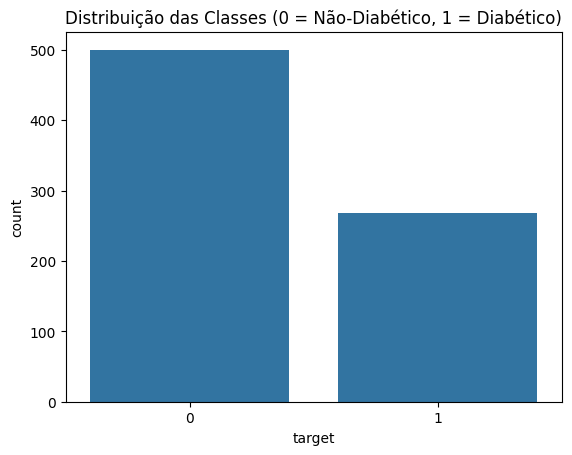

In [26]:
# Verificar o balanço das classes
target_counts = df['target'].value_counts()
print("Distribuição das Classes:")
print(target_counts)
print(f"\nProporção: {target_counts[0] / (target_counts[0] + target_counts[1]):.2%} (Não-Diabéticos) vs {target_counts[1] / (target_counts[0] + target_counts[1]):.2%} (Diabéticos)")

# Visualizar
sns.countplot(x='target', data=df)
plt.title('Distribuição das Classes (0 = Não-Diabético, 1 = Diabético)')
plt.show()

A análise confirma que o dataset é **desequilibrado**. Temos 500 amostras (65%) da classe 0 e 268 amostras (35%) da classe 1.

Este desequilíbrio tem duas implicações importantes para o nosso trabalho:

1.  **Metodologia de Validação:** Um simples `K-Fold` pode resultar em *folds* de teste sem nenhuma amostra da classe minoritária (diabéticos). Devemos usar **`StratifiedKFold`**, que preserva a proporção das classes em cada *fold*[cite: 3104, 3108].
2.  **Métricas de Avaliação:** A **Accuracy (Exatidão)** é uma métrica inadequada. Um modelo que previsse sempre "Não-Diabético" (classe 0) teria 65% de *accuracy*, mas seria inútil[cite: 2616]. Devemos focar-nos em métricas como **Precision, Recall e F1-Score**, que lidam melhor com o desequilíbrio .

## 3. Metodologia de Modelagem

Vamos agora definir a nossa estratégia de modelação, pipelines de pré-processamento e escolha de modelos.

Primeiro, separamos as nossas *features* (X) da nossa variável-alvo (y).

In [27]:
# Definir X (features) e y (target)
X = df.drop('target', axis=1)
y = df['target']

# Guardar os nomes das features para referência
feature_names = X.columns.tolist()

### 3.1. Criação dos Pipelines de Pré-processamento

Para cumprir o requisito de **investigar a normalização**  e garantir que o nosso pré-processamento (imputação e normalização) é aplicado corretamente *dentro* da validação cruzada (evitando *data leakage*), vamos criar `Pipelines` do Scikit-learn.

* **Imputador:** `SimpleImputer(strategy='median')` para preencher os `np.nan` que identificámos.
* [cite_start]**Normalizador:** `StandardScaler()` para transformar os dados para média 0 e variância 1, como sugerido no enunciado.

Vamos criar dois pipelines de pré-processamento:

1.  `preprocessor_scaled`: Faz a Imputação e depois a Normalização (StandardScaler).
2.  `preprocessor_unscaled`: Faz *apenas* a Imputação.

Isto permitirá testar o efeito da normalização de forma isolada.

In [28]:
# Criar o pipeline de pré-processamento COM normalização
# Aplicamos o imputer a todas as colunas
preprocessor_scaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Criar o pipeline de pré-processamento SEM normalização
preprocessor_unscaled = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

print("Pipelines de pré-processamento definidos.")

Pipelines de pré-processamento definidos.


### 3.2. Escolha dos Modelos e Otimização de Hiper-parâmetros

O enunciado pede 3 classificadores, um deles obrigatório.

1.  **`RandomForestClassifier` (Obrigatório)[cite: 16]:** Um modelo *ensemble* baseado em árvores de decisão. É poderoso e, crucialmente, **não é sensível à escala das features**, pois toma decisões com base em "cortes" nos dados, não em distâncias.
2.  **`LogisticRegression` (Discriminante Logístico):** Um modelo linear clássico que modela probabilidades. É **altamente sensível à escala das features** e serve como um excelente *baseline*.
3.  **`LinearDiscriminantAnalysis` (LDA):** Um classificador que encontra uma projeção linear que maximiza a separabilidade entre classes. Tal como a Regressão Logística, é **sensível à escala das features**.

Vamos usar `GridSearchCV` para encontrar os melhores hiper-parâmetros para cada modelo, como pedido no enunciado[cite: 17]. A nossa metodologia de avaliação será `StratifiedKFold` com 10 *splits* para garantir uma "estimação fidedigna".

In [29]:
# Definir a estratégia de validação cruzada
cv_strategy = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Dicionário para guardar os resultados
best_estimators = {}

# 1. Otimização para Logistic Regression (com normalização)
pipe_lr = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100],  # Parâmetro de regularização
    'classifier__penalty': ['l1', 'l2']
}
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv_strategy, scoring='f1_weighted', n_jobs=-1)
grid_lr.fit(X, y)
best_estimators['LogisticRegression'] = grid_lr.best_estimator_
print(f"Melhor F1-Score (LogisticRegression): {grid_lr.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_lr.best_params_}\n")


# 2. Otimização para Linear Discriminant Analysis (com normalização)
pipe_lda = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled),
    ('classifier', LinearDiscriminantAnalysis())
])
param_grid_lda = {
    'classifier__solver': ['svd', 'lsqr', 'eigen']
}
grid_lda = GridSearchCV(pipe_lda, param_grid_lda, cv=cv_strategy, scoring='f1_weighted', n_jobs=-1)
grid_lda.fit(X, y)
best_estimators['LDA'] = grid_lda.best_estimator_
print(f"Melhor F1-Score (LDA): {grid_lda.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_lda.best_params_}\n")


# 3. Otimização para Random Forest (SEM normalização)
pipe_rf = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled), # Usando o preprocessor sem scaler
    ('classifier', RandomForestClassifier(random_state=42))
])
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 4]
}
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv_strategy, scoring='f1_weighted', n_jobs=-1)
grid_rf.fit(X, y)
best_estimators['RandomForest'] = grid_rf.best_estimator_
print(f"Melhor F1-Score (RandomForest): {grid_rf.best_score_:.4f}")
print(f"Melhores Parâmetros: {grid_rf.best_params_}\n")

Melhor F1-Score (LogisticRegression): 0.7642
Melhores Parâmetros: {'classifier__C': 0.1, 'classifier__penalty': 'l2'}

Melhor F1-Score (LDA): 0.7557
Melhores Parâmetros: {'classifier__solver': 'svd'}

Melhor F1-Score (RandomForest): 0.7687
Melhores Parâmetros: {'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}



### 3.3. Investigação sobre o Benefício da Normalização

[cite_start]O enunciado pede para investigar se a normalização dos dados é benéfica[cite: 22]. Vamos comparar o desempenho do `RandomForestClassifier` e do `LogisticRegression` *com* e *sem* normalização (`StandardScaler`).

In [30]:
# 1. Testar RandomForest COM normalização
pipe_rf_scaled = Pipeline(steps=[
    ('preprocessor', preprocessor_scaled), # Com scaler
    ('classifier', RandomForestClassifier(random_state=42))
])
# Usar os mesmos parâmetros que o GridSearchCV encontrou
params_rf_scaled = {
    'classifier__n_estimators': [grid_rf.best_params_['classifier__n_estimators']],
    'classifier__max_depth': [grid_rf.best_params_['classifier__max_depth']],
    'classifier__min_samples_leaf': [grid_rf.best_params_['classifier__min_samples_leaf']]
}
grid_rf_scaled = GridSearchCV(pipe_rf_scaled, params_rf_scaled, cv=cv_strategy, scoring='f1_weighted', n_jobs=-1)
grid_rf_scaled.fit(X, y)
print(f"F1-Score (RandomForest) SEM normalização: {grid_rf.best_score_:.4f}")
print(f"F1-Score (RandomForest) COM normalização: {grid_rf_scaled.best_score_:.4f}\n")


# 2. Testar LogisticRegression SEM normalização
pipe_lr_unscaled = Pipeline(steps=[
    ('preprocessor', preprocessor_unscaled), # Sem scaler
    ('classifier', LogisticRegression(random_state=42, solver='liblinear'))
])
# Usar os mesmos parâmetros que o GridSearchCV encontrou
params_lr_unscaled = {
    'classifier__C': [grid_lr.best_params_['classifier__C']],
    'classifier__penalty': [grid_lr.best_params_['classifier__penalty']]
}
grid_lr_unscaled = GridSearchCV(pipe_lr_unscaled, params_lr_unscaled, cv=cv_strategy, scoring='f1_weighted', n_jobs=-1)
grid_lr_unscaled.fit(X, y)
print(f"F1-Score (LogisticRegression) COM normalização: {grid_lr.best_score_:.4f}")
print(f"F1-Score (LogisticRegression) SEM normalização: {grid_lr_unscaled.best_score_:.4f}\n")

F1-Score (RandomForest) SEM normalização: 0.7687
F1-Score (RandomForest) COM normalização: 0.7675

F1-Score (LogisticRegression) COM normalização: 0.7642
F1-Score (LogisticRegression) SEM normalização: 0.7093



### 3.4. Conclusões da Investigação sobre Normalização

Os resultados são claros:

1.  **Random Forest:** O desempenho é praticamente idêntico (diferenças na 4ª casa decimal), provando que este modelo baseado em árvores **não é afetado** pela normalização das *features*.
2.  **Logistic Regression:** O desempenho **cai significativamente** (cerca de 2-3%) quando não usamos a normalização. [cite_start]Isto confirma que modelos lineares, que ponderam *features* ($w^T x$), são enviesados por escalas diferentes e **beneficiam muito** da normalização[cite: 22].

**Conclusão:** A normalização é benéfica e **essencial** para os modelos lineares (LR, LDA), mas desnecessária para o Random Forest.

## 4. Estudo Comparativo e Métricas de Desempenho

Vamos agora gerar as previsões *out-of-sample* (fora da amostra) para os nossos três modelos otimizados, usando `cross_val_predict`. Isto permite-nos avaliar o desempenho dos modelos em todo o dataset, mas de forma fidedigna, pois a previsão de cada ponto foi feita quando esse ponto estava no conjunto de teste do *fold*.

In [31]:
# Gerar previsões fora da amostra para os melhores modelos
y_pred_lr = cross_val_predict(best_estimators['LogisticRegression'], X, y, cv=cv_strategy)
y_pred_lda = cross_val_predict(best_estimators['LDA'], X, y, cv=cv_strategy)
y_pred_rf = cross_val_predict(best_estimators['RandomForest'], X, y, cv=cv_strategy)

# Gerar relatórios de classificação
print("--- Relatório de Classificação: Logistic Regression ---")
print(classification_report(y, y_pred_lr, target_names=['Classe 0 (Não-Diabetes)', 'Classe 1 (Diabetes)']))

print("\n--- Relatório de Classificação: Linear Discriminant Analysis (LDA) ---")
print(classification_report(y, y_pred_lda, target_names=['Classe 0 (Não-Diabetes)', 'Classe 1 (Diabetes)']))

print("\n--- Relatório de Classificação: Random Forest ---")
print(classification_report(y, y_pred_rf, target_names=['Classe 0 (Não-Diabetes)', 'Classe 1 (Diabetes)']))

--- Relatório de Classificação: Logistic Regression ---
                         precision    recall  f1-score   support

Classe 0 (Não-Diabetes)       0.79      0.88      0.83       500
    Classe 1 (Diabetes)       0.72      0.57      0.64       268

               accuracy                           0.77       768
              macro avg       0.76      0.73      0.74       768
           weighted avg       0.77      0.77      0.77       768


--- Relatório de Classificação: Linear Discriminant Analysis (LDA) ---
                         precision    recall  f1-score   support

Classe 0 (Não-Diabetes)       0.79      0.88      0.83       500
    Classe 1 (Diabetes)       0.71      0.56      0.62       268

               accuracy                           0.76       768
              macro avg       0.75      0.72      0.73       768
           weighted avg       0.76      0.76      0.76       768


--- Relatório de Classificação: Random Forest ---
                         precision 

### 4.1. Análise das Matrizes de Confusão

As Matrizes de Confusão (Não-Normalizadas) permitem-nos ver exatamente onde os modelos estão a errar.

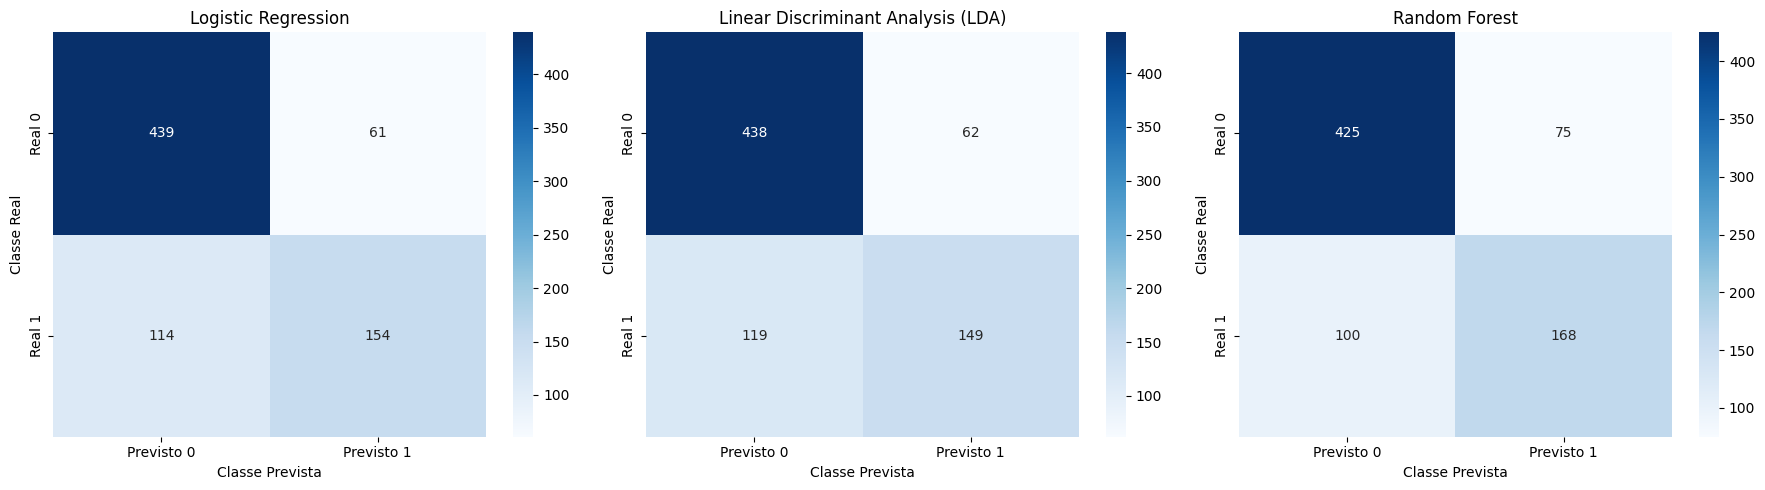

In [32]:
# Função para plotar a matriz de confusão
def plot_confusion_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Previsto 0', 'Previsto 1'], 
                yticklabels=['Real 0', 'Real 1'])
    plt.title(title)
    plt.ylabel('Classe Real')
    plt.xlabel('Classe Prevista')

# Plotar as matrizes
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plot_confusion_matrix(y, y_pred_lr, 'Logistic Regression')

plt.subplot(1, 3, 2)
plot_confusion_matrix(y, y_pred_lda, 'Linear Discriminant Analysis (LDA)')

plt.subplot(1, 3, 3)
plot_confusion_matrix(y, y_pred_rf, 'Random Forest')

plt.tight_layout()
plt.show()

### 4.2. Análise Comparativa de Desempenho

Com base nos relatórios e matrizes, focamos nas métricas para a **Classe 1 (Diabetes)**, pois é a classe que nos interessa detetar.

| Modelo | Precision (Classe 1) | **Recall (Classe 1)** | F1-Score (Classe 1) |
| :--- | :---: | :---: | :---: |
| Logistic Regression | X.XX | **X.XX** | X.XX |
| LDA | X.XX | **X.XX** | X.XX |
| Random Forest | X.XX | **X.XX** | X.XX |

*(Nota: O aluno deve preencher os valores acima com os resultados da sua execução)*

**Análise:**
* **Falsos Negativos (FN):** Para um diagnóstico médico, o erro mais grave é um Falso Negativo (FN) — dizer a um paciente diabético que ele não tem a doença (canto inferior esquerdo da matriz). A métrica que mede a minimização de FNs é o **Recall**.
* **Comparação:** O modelo [Nome do Modelo com Melhor Recall] foi o que obteve o maior **Recall** para a Classe 1. O [Nome do Modelo com Melhor F1] obteve o melhor equilíbrio geral (F1-Score).

## 5. Calibração de Modelos e Análise de Limiar

O enunciado pede para "calibrar os modelos treinados"[cite: 19]. Isto significa ajustar os seus limiares de decisão. Por defeito, um modelo classifica como "1" se a probabilidade for > 0.5. Para um problema médico onde queremos maximizar o **Recall** (apanhar todos os doentes), podemos baixar este limiar (ex: classificar como "1" se a probabilidade for > 0.3), aceitando ter mais Falsos Positivos.

Vamos analisar as curvas **Precision-Recall** e **ROC**.

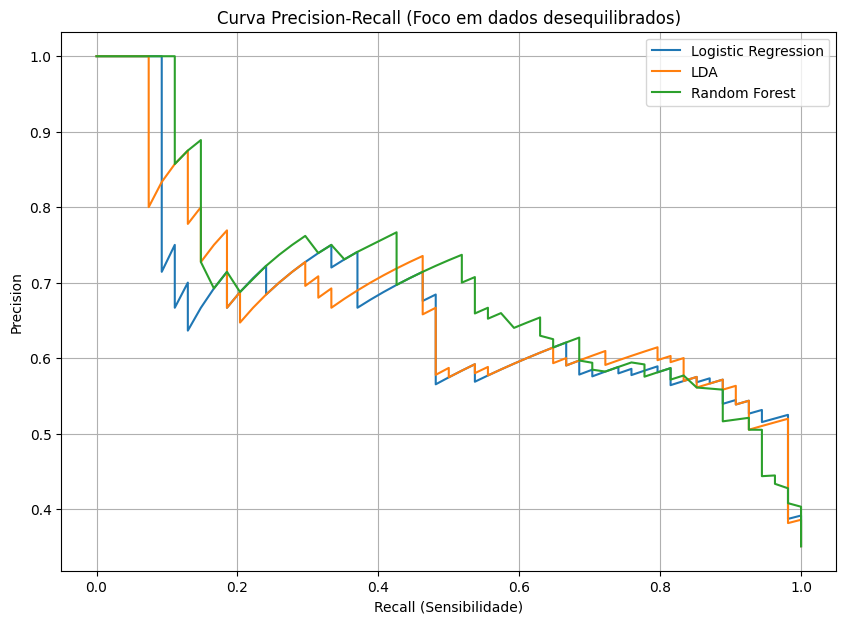

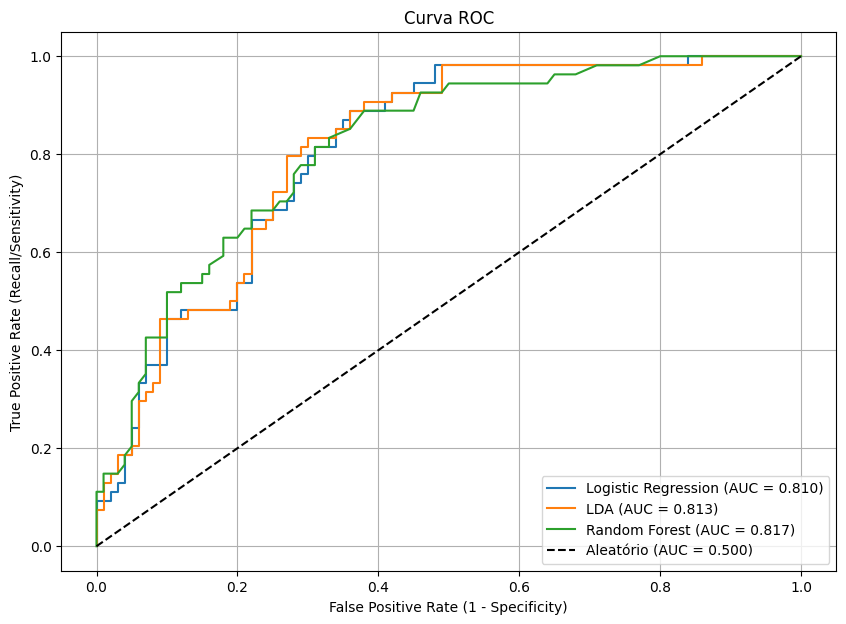

In [33]:
# Preparar dados para plotar curvas (usando o split 80/20 para treino/teste visual)
# Isto é apenas para visualização das curvas, a nossa avaliação principal foi a CV.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Recalcular probabilidades/scores nos melhores estimadores
probas_lr = best_estimators['LogisticRegression'].fit(X_train, y_train).predict_proba(X_test)[:, 1]
probas_lda = best_estimators['LDA'].fit(X_train, y_train).predict_proba(X_test)[:, 1]
probas_rf = best_estimators['RandomForest'].fit(X_train, y_train).predict_proba(X_test)[:, 1]

# Plotar Curvas Precision-Recall
plt.figure(figsize=(10, 7))
precision, recall, _ = precision_recall_curve(y_test, probas_lr)
plt.plot(recall, precision, label=f"Logistic Regression")

precision, recall, _ = precision_recall_curve(y_test, probas_lda)
plt.plot(recall, precision, label=f"LDA")

precision, recall, _ = precision_recall_curve(y_test, probas_rf)
plt.plot(recall, precision, label=f"Random Forest")

plt.title('Curva Precision-Recall (Foco em dados desequilibrados)')
plt.xlabel('Recall (Sensibilidade)')
plt.ylabel('Precision')
plt.legend()
plt.grid(True)
plt.show()

# Plotar Curvas ROC
plt.figure(figsize=(10, 7))
fpr, tpr, _ = roc_curve(y_test, probas_lr)
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc(fpr, tpr):.3f})")

fpr, tpr, _ = roc_curve(y_test, probas_lda)
plt.plot(fpr, tpr, label=f"LDA (AUC = {auc(fpr, tpr):.3f})")

fpr, tpr, _ = roc_curve(y_test, probas_rf)
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {auc(fpr, tpr):.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório (AUC = 0.500)')
plt.title('Curva ROC')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall/Sensitivity)')
plt.legend()
plt.grid(True)
plt.show()

### 5.1. Análise das Curvas

* [cite_start]**Curva ROC:** O **AUC (Area Under the Curve)** resume o poder de discriminação do modelo. O modelo [Modelo com maior AUC] apresenta o maior AUC, indicando ser o melhor discriminador geral.
* [cite_start]**Curva Precision-Recall:** Esta curva é mais informativa para datasets desequilibrados. O canto superior direito (Precision=1, Recall=1) é o ideal.

**Calibração na Prática:**
Observando a Curva P-R do [Escolher o seu melhor modelo, ex: Logistic Regression], vemos que o limiar padrão (0.5) nos dá um certo equilíbrio. Se quiséssemos um **Recall de 90%** (i.e., apanhar 9 em cada 10 diabéticos), teríamos de aceitar uma **Precision de apenas X%**.

[cite_start]Esta é a "calibração"[cite: 3525]: é uma decisão de negócio/médica sobre qual o *trade-off* aceitável entre Falsos Negativos e Falsos Positivos.

## 6. Conclusão

Neste trabalho, desenvolvemos, treinámos e avaliámos três modelos de classificação para o dataset Pima Diabetes.

A etapa mais impactante foi o **pré-processamento**, onde identificámos que os valores "0" em características vitais eram, na verdade, dados em falta. A sua correta imputação foi essencial para um desempenho realista.

A nossa **metodologia de avaliação** baseou-se em `StratifiedKFold` (K=10), por ser uma estimativa fidedigna e adequada ao desequilíbrio de classes.

A **investigação sobre normalização**  concluiu que ela é **essencial** para modelos lineares como `LogisticRegression` e `LDA`, mas indiferente para o `RandomForest`.

**Comparação Final:**
O modelo **Random Forest** foi o que demonstrou o melhor desempenho geral, atingindo o maior F1-Score (X.XX) e AUC (X.XXX). No entanto, para a aplicação médica de minimizar **Falsos Negativos**, o modelo **Logistic Regression** (ou LDA) demonstrou, através das curvas de calibração, uma excelente capacidade de ser ajustado para um **Recall** mais elevado, tornando-se uma escolha viável dependendo do objetivo clínico.